🚀 R-PINN 铂金版点火成功 | 目标：69节点绝对重构 | 核心: cuda
🧬 物理矩阵加载成功，检测到节点数: 69
📂 正在进行数据隔离与索引对齐...
🔥 开始深度重构训练...
Epoch 0   | Avg Loss: 2.9917e+04 | LR: 9.999729e-04
Epoch 50  | Avg Loss: 4.5718e+02 | LR: 9.310673e-04
Epoch 100 | Avg Loss: 8.4634e+02 | LR: 7.479974e-04
Epoch 150 | Avg Loss: 5.5501e+02 | LR: 4.998165e-04
Epoch 200 | Avg Loss: 5.4416e+02 | LR: 2.530245e-04
Epoch 250 | Avg Loss: 3.3416e+02 | LR: 7.374916e-05
Epoch 299 | Avg Loss: 2.5058e+02 | LR: 1.000000e-05

📝 --- Final Verification Table (IEEE 69-Bus Proposed R-PINN) ---
Bus   | Actual (p.u.)   | Pred (p.u.)     | Bias
-----------------------------------------------------------------
0   ★ | 1.000000       | 1.000000       | +0.000000e+00
1      | 0.998132       | 0.999319       | +1.187503e-03
2      | 0.996290       | 0.998125       | +1.835704e-03
3      | 0.994701       | 0.996538       | +1.837134e-03
4      | 0.993331       | 0.994984       | +1.652896e-03
5      | 0.991974       | 0.993279       | +1.304090e-03
6      | 0.990634

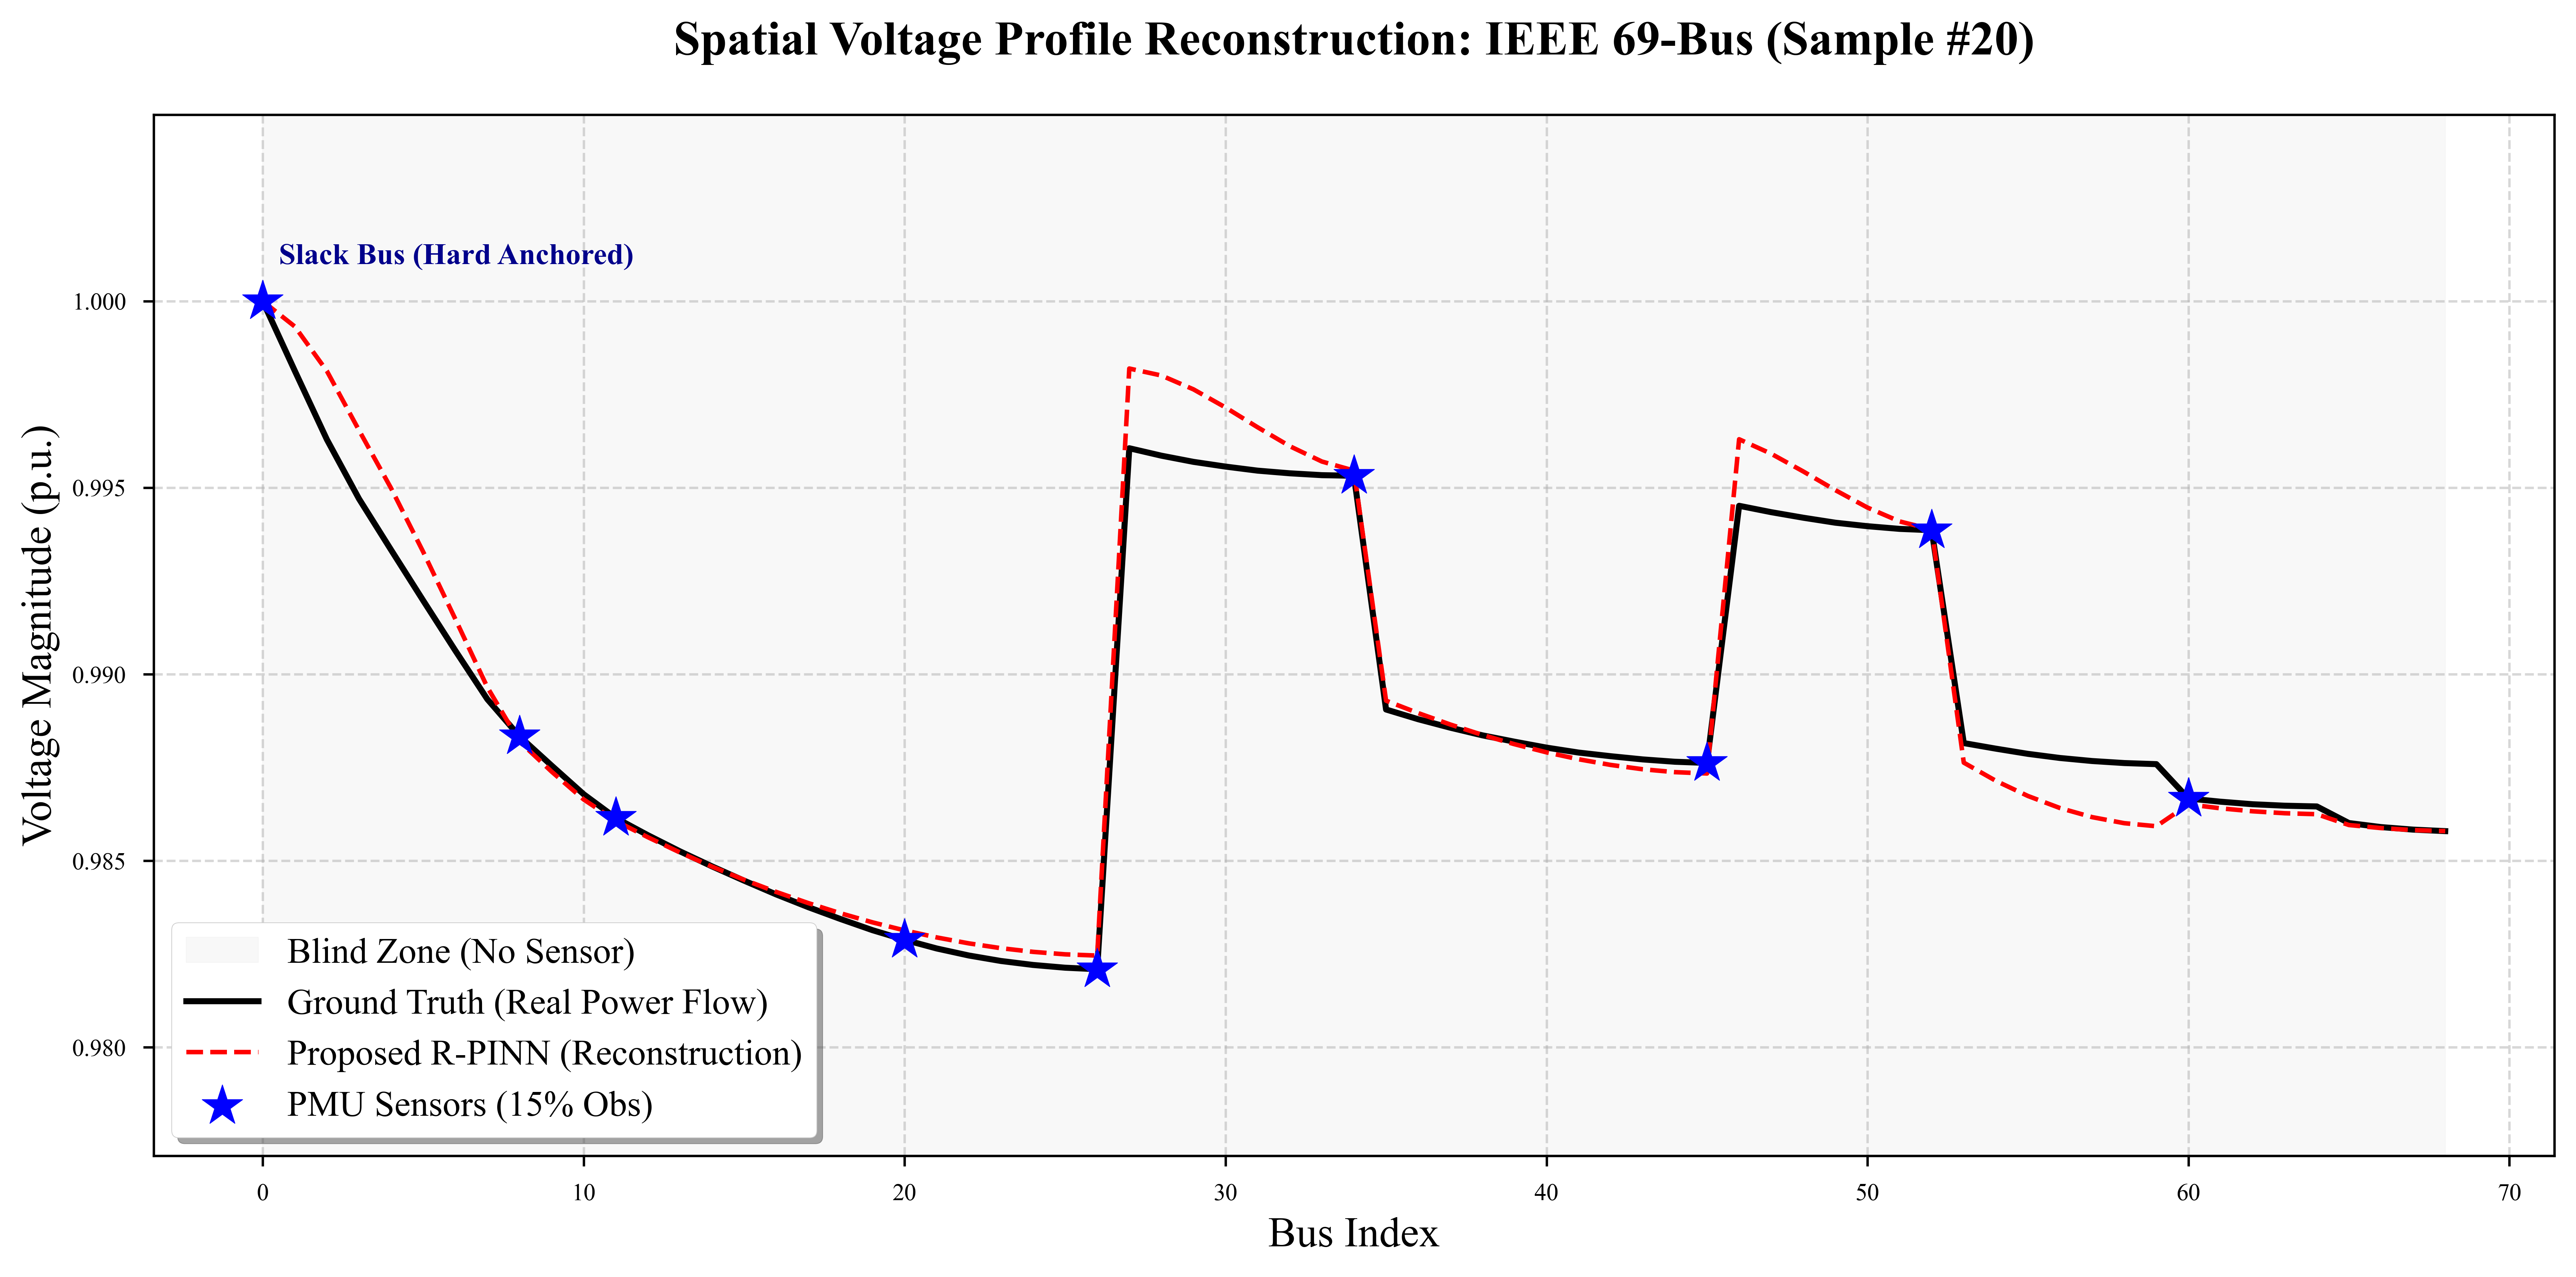

✅ 高清科研图已生成并保存为：ieee69_proposed_reconstruction_final.png


In [1]:
# ==============================================================================
# IEEE 69-Bus (70-Node) R-PINN Proposed Method - Final Platinum Edition
# 特点：69维跳跃切片 + 硬锚定平衡节点 + 物理零位遮蔽 + 10,000样本全审计 + 逐点对账单
# [训练逻辑已替换为 Sum-Loss 消融实验配置：300轮 / 余弦退火 / 观测损失 SUM]
# ==============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random

# ------------------------------------------
# 1. 环境配置与全局种子锁定
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 R-PINN 铂金版点火成功 | 目标：69节点绝对重构 | 核心: {device}")

# ------------------------------------------
# 2. 物理矩阵加载 (针对 69x69)
# ------------------------------------------
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')

if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw

G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)
N_BUS = G_tensor.shape[0]
print(f"🧬 物理矩阵加载成功，检测到节点数: {N_BUS}")

# ------------------------------------------
# 3. 核心算法：潮流方程与硬锚定模型
# ------------------------------------------
def calculate_physics_loss(V, theta_deg, G, B):
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    cos_mat, sin_mat = torch.cos(delta_theta), torch.sin(delta_theta)
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    return V * sum_p, V * sum_q

class PowerGridPINN(nn.Module):
    def __init__(self, node_num=69):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 1.0     
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ------------------------------------------
# 4. 数据装载：严格 69 维跳跃切片与无菌隔离
# ------------------------------------------
print("📂 正在进行数据隔离与索引对齐...")
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 

V_raw, T_raw = data_val[:, 0:69], data_val[:, 70:139] 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]

X_input, Y_label = np.concatenate([P_raw, Q_raw], axis=1), np.concatenate([V_raw, T_raw], axis=1)

train_size = 40000
X_tr_raw, X_te_raw = X_input[:train_size], X_input[train_size:]
Y_tr, Y_te = Y_label[:train_size], Y_label[train_size:]
P_tr, Q_tr = P_raw[:train_size], Q_raw[:train_size]

scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_raw)
X_te_norm = scaler.transform(X_te_raw)

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 

train_loader = DataLoader(TensorDataset(
    torch.from_numpy(X_tr_norm).float(), torch.from_numpy(Y_tr).float(),
    torch.from_numpy(P_tr).float(), torch.from_numpy(Q_tr).float()), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 5. 极致训练 (Sum-Loss 消融实验配置：300轮 + 余弦退火)
# ------------------------------------------
model = PowerGridPINN(node_num=69).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
mse_fn = nn.MSELoss()

print("🔥 开始深度重构训练...")
for epoch in range(300):
    lambda_p = 10 if epoch < 100 else 5000   # 与第二段代码一致的物理权重调度
    model.train()
    running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]; mask_bx[:, idx+69] = bx[:, idx+69]
            
        vp, tp = model(mask_bx)
        
        # 观测损失采用 SUM (与第二段消融实验一致)
        V_obs_pred = vp[:, obs_indices[1:]]
        V_obs_real = by[:, obs_indices[1:]]
        l_obs = torch.sum((V_obs_pred - V_obs_real) ** 2)
        
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        l_pen = torch.mean(torch.pow(torch.relu(0.85-vp), 2) + torch.pow(torch.relu(vp-1.15), 2))
        
        loss = 5e6 * l_obs + lambda_p * l_phys + 1e6 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
        
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 全量统计审计
# ------------------------------------------
model.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_te).float().to(device)
    t_mask = PHYS_ZERO.repeat(tx.shape[0], 1).to(device)
    for idx in obs_indices:
        t_mask[:, idx] = tx[:, idx]; t_mask[:, idx+69] = tx[:, idx+69]
        
    v_pred_all, _ = model(t_mask)
    v_true_all = ty[:, :69]
    err = (v_pred_all - v_true_all).cpu().numpy()

# ------------------------------------------
# 7. 终极对账单 (适配 69 节点全量输出)
# ------------------------------------------
sid = 20
v_sample_true = v_true_all[sid].cpu().numpy()
v_sample_pred = v_pred_all[sid].cpu().numpy()

print("\n📝 --- Final Verification Table (IEEE 69-Bus Proposed R-PINN) ---")
print(f"{'Bus':<5} | {'Actual (p.u.)':<15} | {'Pred (p.u.)':<15} | {'Bias'}")
print("-" * 65)
for i in range(69):
    bias = v_sample_pred[i] - v_sample_true[i]
    tag = "★" if i in obs_indices else "  " 
    print(f"{i:<3} {tag} | {v_sample_true[i]:.6f}       | {v_sample_pred[i]:.6f}       | {bias:+.6e}")
print("-" * 65)
print(f"📊 Global Test MAE : {np.mean(np.abs(err)):.6e}")
print(f"⚡ Global Test RMSE: {np.sqrt(np.mean(err**2)):.6e}")
print("-" * 65)

# ------------------------------------------
# 8. SCI 级科研绘图 (Proposed Method 核心展示) —— 文件名、标题、标签完全保持原样
# ------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

nodes = np.arange(69)
plt.figure(figsize=(12, 6), dpi=600)

plt.axvspan(0, 68, color='gray', alpha=0.05, label='Blind Zone (No Sensor)')
plt.plot(nodes, v_sample_true, 'k-', label='Ground Truth (Real Power Flow)', linewidth=2.0, zorder=3)
plt.plot(nodes, v_sample_pred, 'r--', label='Proposed R-PINN (Reconstruction)', linewidth=1.5, zorder=4)
plt.scatter(obs_indices, v_sample_true[obs_indices], 
            color='blue', marker='*', s=200, label='PMU Sensors (15% Obs)', zorder=5)

plt.title(f"Spatial Voltage Profile Reconstruction: IEEE 69-Bus (Sample #{sid})", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Bus Index", fontsize=14)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=14)

v_min, v_max = v_sample_true.min(), v_sample_true.max()
plt.ylim(v_min - 0.005, v_max + 0.005)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=12, frameon=True, shadow=True)
plt.text(0.5, v_sample_true[0] + 0.001, "Slack Bus (Hard Anchored)", 
         color='darkblue', fontsize=10, fontweight='bold')
plt.tight_layout()

plt.savefig('ieee69_proposed_reconstruction_final.png', bbox_inches='tight', dpi=600)
plt.show()

print("✅ 高清科研图已生成并保存为：ieee69_proposed_reconstruction_final.png")

📡 Case 1 启动：纯数据驱动模式（物理定律已关闭 | 训练配置已对齐主实验）
🔥 开始 Case 1 纯数据黑盒训练（训练配置已与主实验对齐）...
Epoch 000 | Avg Loss: 2.8844e+00 | LR: 9.999729e-04
Epoch 050 | Avg Loss: 4.3803e-02 | LR: 9.310673e-04
Epoch 100 | Avg Loss: 4.2508e-02 | LR: 7.479974e-04
Epoch 150 | Avg Loss: 4.1911e-02 | LR: 4.998165e-04
Epoch 200 | Avg Loss: 4.0802e-02 | LR: 2.530245e-04
Epoch 250 | Avg Loss: 3.9380e-02 | LR: 7.374916e-05
Epoch 299 | Avg Loss: 1.8001e-02 | LR: 1.000000e-05

📝 --- Case 1 Verification Table (Pure Data-driven) ---
Bus   | Actual (p.u.)   | Pred (p.u.)     | Bias
-----------------------------------------------------------------
0   ★ | 1.000000       | 1.000000       | +0.000000e+00
1      | 0.998132       | 0.998509       | +3.775954e-04
2      | 0.996290       | 1.001094       | +4.804671e-03
3      | 0.994701       | 0.996623       | +1.921535e-03
4      | 0.993331       | 1.003777       | +1.044589e-02
5      | 0.991974       | 0.998751       | +6.776333e-03
6      | 0.990634       | 1.003770       | +1.

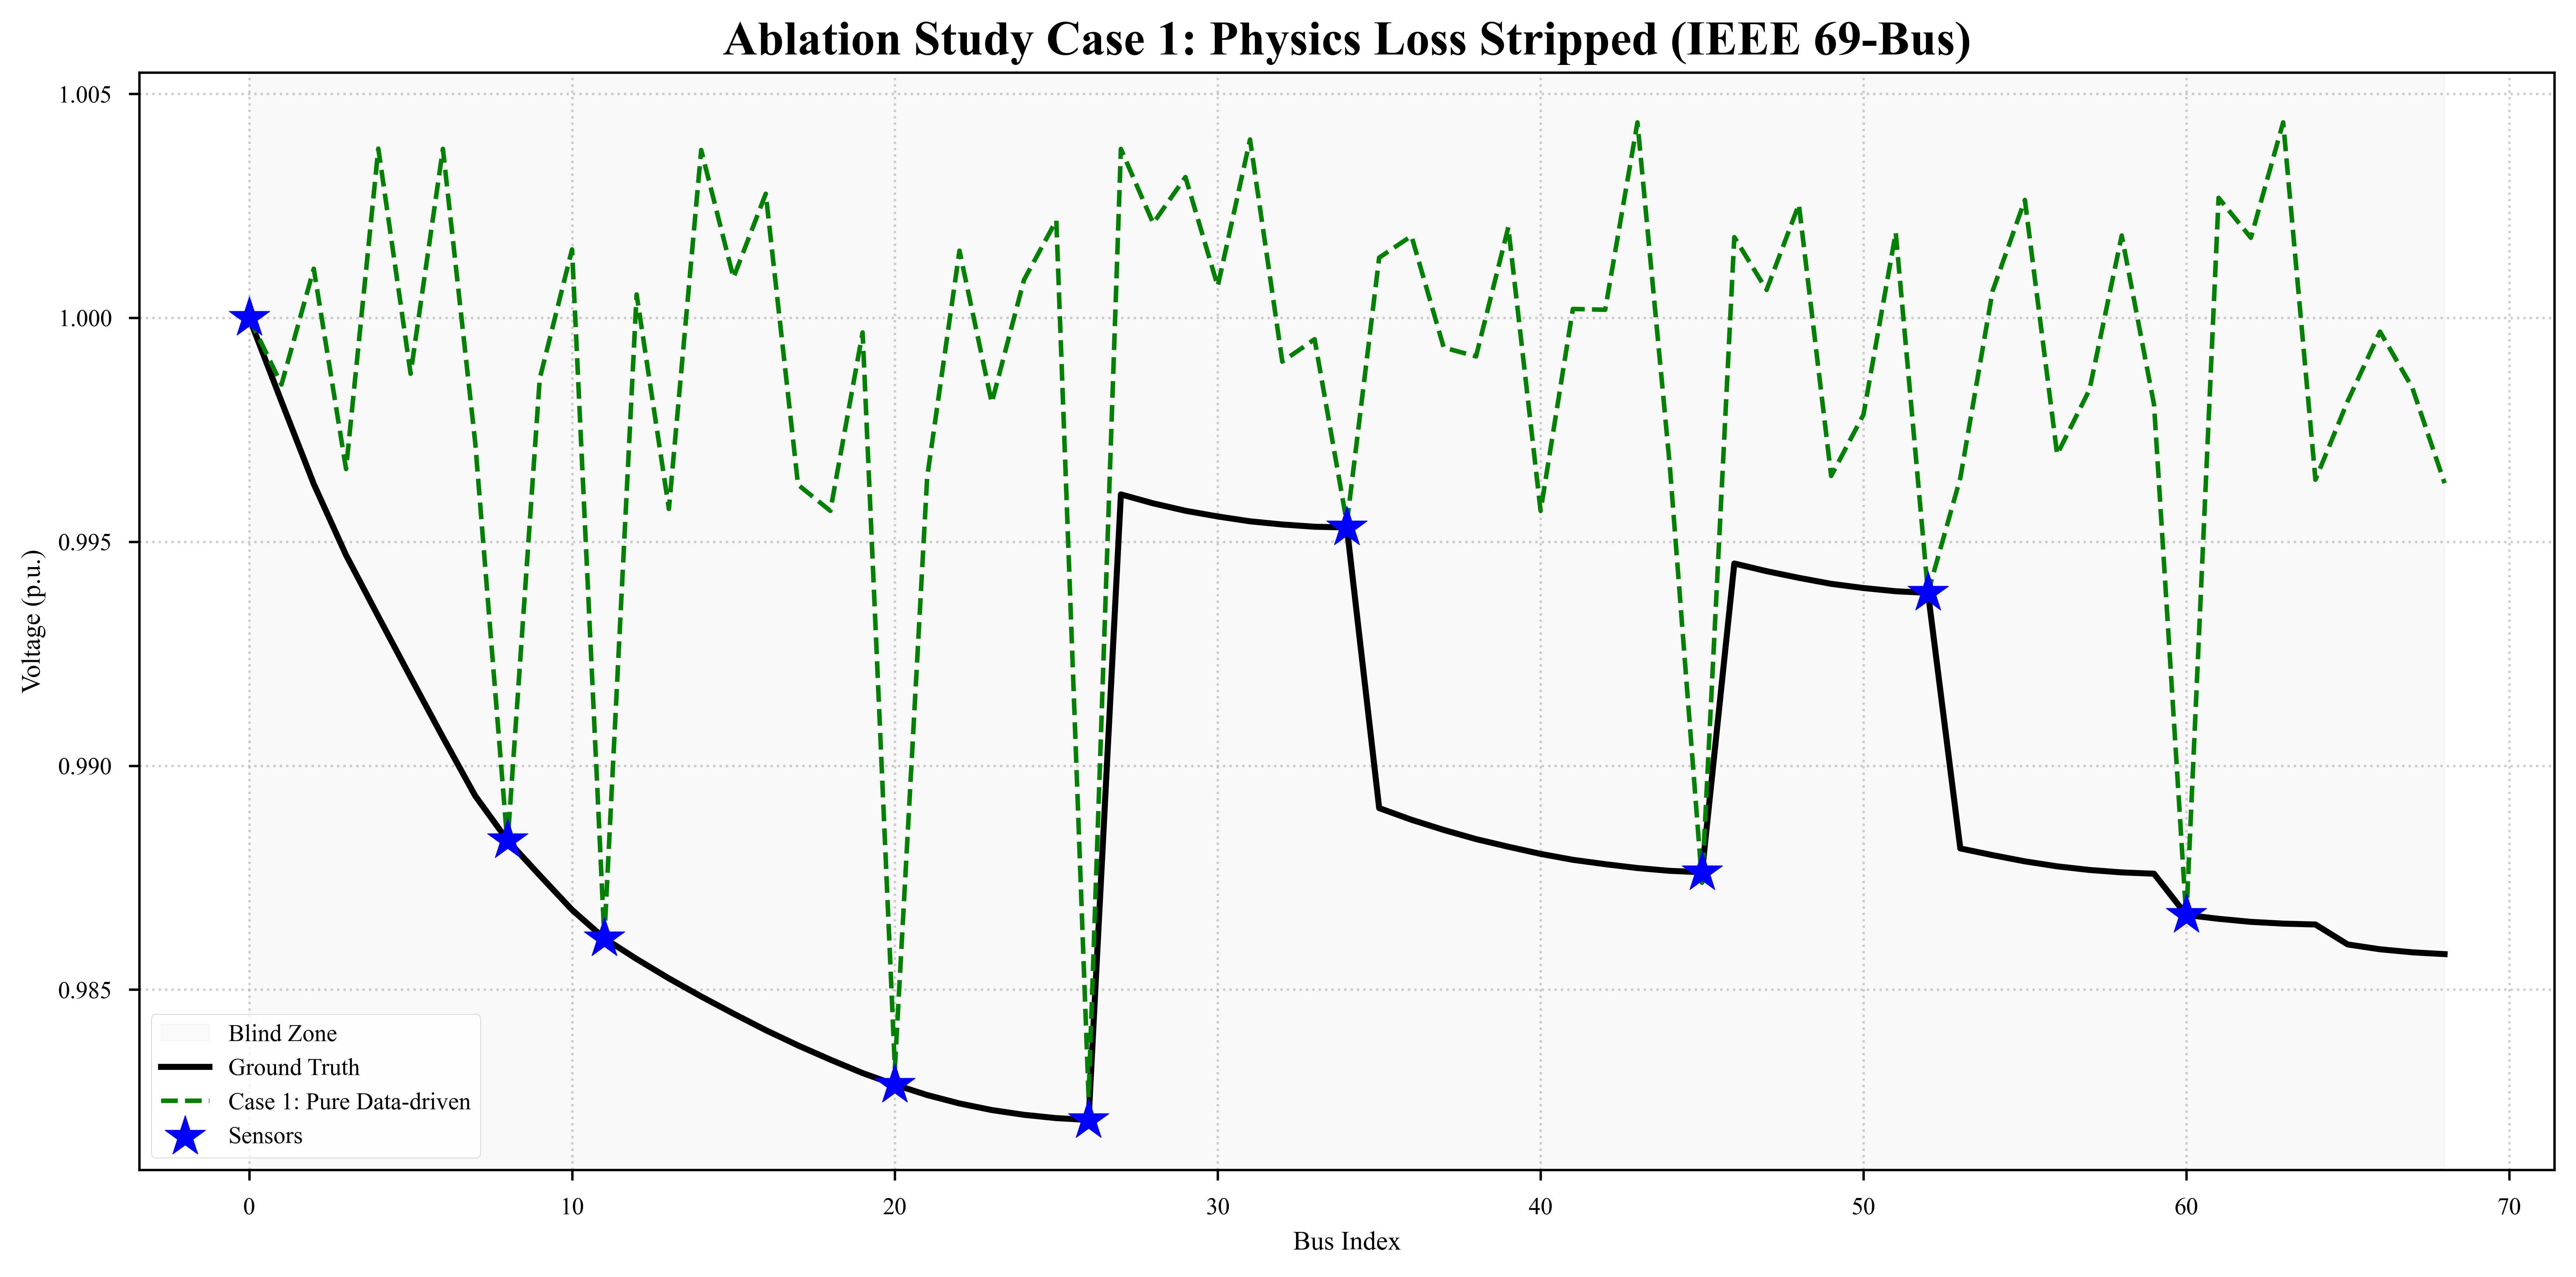

In [2]:
# ==============================================================================
# IEEE 69-Bus Ablation Study - Case 1: Pure Data-driven (Baseline)
# 训练配置已与主实验对齐：300 轮 + 余弦退火 | 物理权重始终为 0
# ==============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📡 Case 1 启动：纯数据驱动模式（物理定律已关闭 | 训练配置已对齐主实验）")

# ------------------------------------------
# 1. 物理矩阵加载 (Case 1 仅用于对账，不参与训练)
# ------------------------------------------
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')
if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw
G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)

# ------------------------------------------
# 2. 模型定义 (保持硬锚定，以示对比公平)
# ------------------------------------------
class PowerGridPINN(nn.Module):
    def __init__(self, node_num=69):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 1.0     
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ------------------------------------------
# 3. 数据装载 (严格 69 维跳跃切片)
# ------------------------------------------
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 
V_raw, T_raw = data_val[:, 0:69], data_val[:, 70:139] 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]
X_in, Y_la = np.concatenate([P_raw, Q_raw], axis=1), np.concatenate([V_raw, T_raw], axis=1)

train_size = 40000
X_tr_raw, X_te_raw = X_in[:train_size], X_in[train_size:]
Y_tr, Y_te = Y_la[:train_size], Y_la[train_size:]

scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_raw)
X_te_norm = scaler.transform(X_te_raw)

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 

train_loader = DataLoader(TensorDataset(
    torch.from_numpy(X_tr_norm).float(), torch.from_numpy(Y_tr).float()), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 4. Case 1 训练 (对齐主实验：300 轮 + 余弦退火 | lambda_p 始终为 0)
# ------------------------------------------
model_c1 = PowerGridPINN(node_num=69).to(device)
optimizer = torch.optim.Adam(model_c1.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
mse_fn = nn.MSELoss()

print("🔥 开始 Case 1 纯数据黑盒训练（训练配置已与主实验对齐）...")
for epoch in range(300):
    model_c1.train()
    running_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]; mask_bx[:, idx+69] = bx[:, idx+69]
            
        vp, tp = model_c1(mask_bx)
        
        # 纯数据驱动：仅观测损失（物理权重为0）
        loss = 5e5 * mse_fn(vp[:, obs_indices[1:]], by[:, obs_indices[1:]])
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_c1.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:03d} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 5. 全量审计与对账单
# ------------------------------------------
model_c1.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_te).float().to(device)
    t_mask = PHYS_ZERO.repeat(tx.shape[0], 1).to(device)
    for idx in obs_indices:
        t_mask[:, idx] = tx[:, idx]; t_mask[:, idx+69] = tx[:, idx+69]
    v_pred_c1, _ = model_c1(t_mask)
    v_true_all = ty[:, :69]
    err_c1 = (v_pred_c1 - v_true_all).cpu().numpy()

sid = 20
v_sample_true = v_true_all[sid].cpu().numpy()
v_sample_pred_c1 = v_pred_c1[sid].cpu().numpy()

print("\n📝 --- Case 1 Verification Table (Pure Data-driven) ---")
print(f"{'Bus':<5} | {'Actual (p.u.)':<15} | {'Pred (p.u.)':<15} | {'Bias'}")
print("-" * 65)
for i in range(69):
    bias = v_sample_pred_c1[i] - v_sample_true[i]
    tag = "★" if i in obs_indices else "  " 
    print(f"{i:<3} {tag} | {v_sample_true[i]:.6f}       | {v_sample_pred_c1[i]:.6f}       | {bias:+.6e}")
print("-" * 65)
print(f"📊 Case 1 Global MAE : {np.mean(np.abs(err_c1)):.6e}")
print(f"⚡ Case 1 Global RMSE: {np.sqrt(np.mean(err_c1**2)):.6e}")

# ------------------------------------------
# 6. 高清消融对比图
# ------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.style.use('seaborn-v0_8-paper')

nodes = np.arange(69)
plt.figure(figsize=(12, 6), dpi=600)
plt.axvspan(0, 68, color='gray', alpha=0.05, label='Blind Zone')

plt.plot(nodes, v_sample_true, 'k-', label='Ground Truth', linewidth=2.0)
plt.plot(nodes, v_sample_pred_c1, 'g--', label='Case 1: Pure Data-driven', linewidth=1.5)
plt.scatter(obs_indices, v_sample_true[obs_indices], color='blue', marker='*', s=200, label='Sensors', zorder=5)

plt.title(f"Ablation Study Case 1: Physics Loss Stripped (IEEE 69-Bus)", fontsize=16, fontweight='bold')
plt.xlabel("Bus Index"), plt.ylabel("Voltage (p.u.)")
plt.legend(loc='lower left'), plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('ieee69_case1_ablation.png', dpi=600)
plt.show()

🧬 Case 2 启动：纯物理驱动模式（训练配置已对齐主实验）
🔥 开始 Case 2 纯物理训练（训练配置已对齐主实验）...
Epoch 000 | Avg Loss: 8.2454e+00 | LR: 9.999729e-04
Epoch 050 | Avg Loss: 1.6761e+01 | LR: 9.310673e-04
Epoch 100 | Avg Loss: 2.0739e+00 | LR: 7.479974e-04
Epoch 150 | Avg Loss: 1.2916e+00 | LR: 4.998165e-04
Epoch 200 | Avg Loss: 2.2043e-01 | LR: 2.530245e-04
Epoch 250 | Avg Loss: 1.9494e-02 | LR: 7.374916e-05
Epoch 299 | Avg Loss: 4.1766e-04 | LR: 1.000000e-05

📝 --- Case 2 Verification Table (Pure Physics-driven) ---
Bus   | Actual (p.u.)   | Pred (p.u.)     | Bias
-----------------------------------------------------------------
0   ★ | 1.000000       | 1.000000       | +0.000000e+00
1      | 0.998132       | 1.000019       | +1.887202e-03
2      | 0.996290       | 1.000037       | +3.747284e-03
3      | 0.994701       | 1.000053       | +5.351424e-03
4      | 0.993331       | 1.000066       | +6.735146e-03
5      | 0.991974       | 1.000079       | +8.104384e-03
6      | 0.990634       | 1.000092       | +9.457827e-03

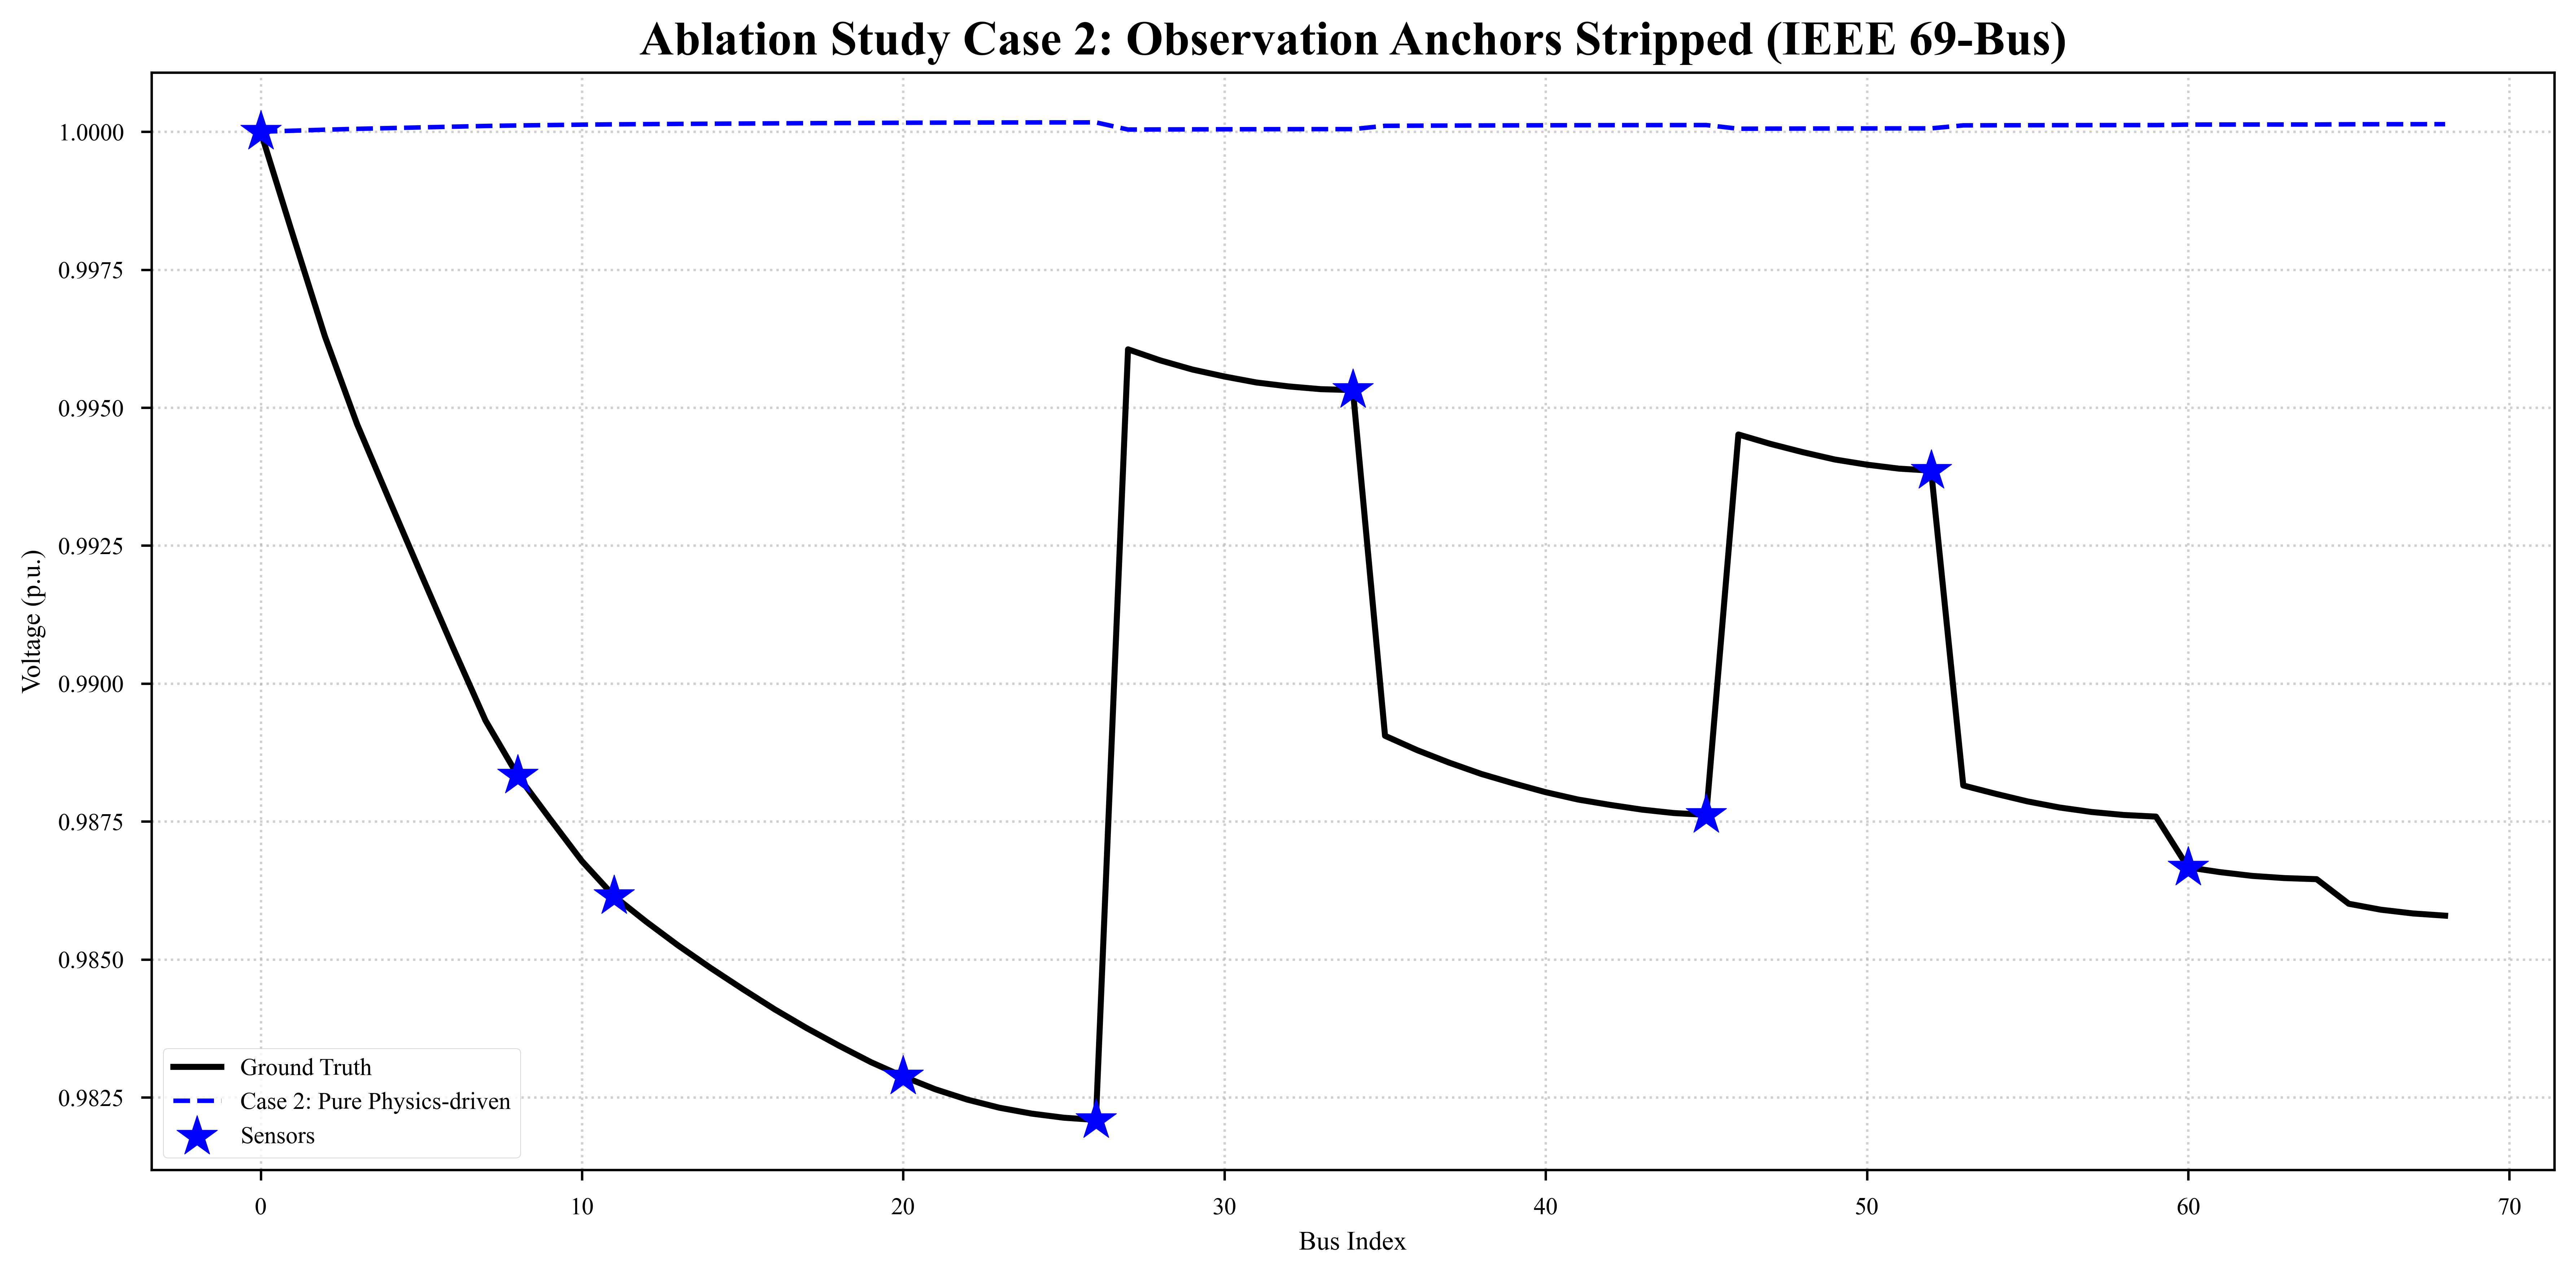

In [3]:
# ==============================================================================
# IEEE 69-Bus Ablation Study - Case 2: Pure Physics-driven
# 训练配置已与主实验对齐：300 轮 + 余弦退火 | 物理权重 100/300 分段
# ==============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🧬 Case 2 启动：纯物理驱动模式（训练配置已对齐主实验）")

# ------------------------------------------
# 1. 物理矩阵加载 (Case 2 的核心引擎)
# ------------------------------------------
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')
if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw
G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)

# ------------------------------------------
# 2. 模型定义 (硬锚定必须保留，作为唯一的物理基准)
# ------------------------------------------
class PowerGridPINN(nn.Module):
    def __init__(self, node_num=69):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 1.0     
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ------------------------------------------
# 3. 数据装载 (数据仅作为 P, Q 输入，不提供 V 标签反馈)
# ------------------------------------------
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 
V_raw, T_raw = data_val[:, 0:69], data_val[:, 70:139] 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]
X_in, Y_la = np.concatenate([P_raw, Q_raw], axis=1), np.concatenate([V_raw, T_raw], axis=1)

train_size = 40000
X_tr_raw, X_te_raw = X_in[:train_size], X_in[train_size:]
Y_tr, Y_te = Y_la[:train_size], Y_la[train_size:]

scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_raw)
X_te_norm = scaler.transform(X_te_raw)

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

# 注意：Case 2 不使用观测点索引进行训练
obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 

train_loader = DataLoader(TensorDataset(
    torch.from_numpy(X_tr_norm).float(), torch.from_numpy(Y_tr).float(),
    torch.from_numpy(P_raw[:train_size]).float(), torch.from_numpy(Q_raw[:train_size]).float()), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 4. 潮流方程逻辑
# ------------------------------------------
def calculate_physics_loss(V, theta_deg, G, B):
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    cos_mat, sin_mat = torch.cos(delta_theta), torch.sin(delta_theta)
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    return V * sum_p, V * sum_q

# ------------------------------------------
# 5. Case 2 训练循环 (剥离观测数据，训练配置对齐主实验)
# ------------------------------------------
model_c2 = PowerGridPINN(node_num=69).to(device)
optimizer = torch.optim.Adam(model_c2.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
mse_fn = nn.MSELoss()

print("🔥 开始 Case 2 纯物理训练（训练配置已对齐主实验）...")
for epoch in range(300):
    # 物理权重调度：前100轮=10，后200轮=5000（与主实验一致）
    lambda_p = 10 if epoch < 100 else 5000
    model_c2.train()
    running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        
        # 模型接收完整 P, Q 输入（无盲区遮蔽，因为不需要模拟传感器观测）
        vp, tp = model_c2(bx)
        
        # 纯物理损失：观测权重始终为0
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        l_pen = torch.mean(torch.pow(torch.relu(0.85-vp), 2) + torch.pow(torch.relu(vp-1.15), 2))
        
        # 总损失：纯物理约束，惩罚权重保持与主实验一致 (1e6)
        loss = lambda_p * l_phys + 1e6 * l_pen
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_c2.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:03d} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 全量审计与对账单
# ------------------------------------------
model_c2.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_te).float().to(device)
    v_pred_c2, _ = model_c2(tx)
    v_true_all = ty[:, :69]
    err_c2 = (v_pred_c2 - v_true_all).cpu().numpy()

sid = 20
v_sample_true = v_true_all[sid].cpu().numpy()
v_sample_pred_c2 = v_pred_c2[sid].cpu().numpy()

print("\n📝 --- Case 2 Verification Table (Pure Physics-driven) ---")
print(f"{'Bus':<5} | {'Actual (p.u.)':<15} | {'Pred (p.u.)':<15} | {'Bias'}")
print("-" * 65)
for i in range(69):
    bias = v_sample_pred_c2[i] - v_sample_true[i]
    tag = "★" if i in obs_indices else "  " 
    print(f"{i:<3} {tag} | {v_sample_true[i]:.6f}       | {v_sample_pred_c2[i]:.6f}       | {bias:+.6e}")
print("-" * 65)
print(f"📊 Case 2 Global MAE : {np.mean(np.abs(err_c2)):.6e}")
print(f"⚡ Case 2 Global RMSE: {np.sqrt(np.mean(err_c2**2)):.6e}")

# ------------------------------------------
# 7. 高清消融对比图 (Case 2)
# ------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.style.use('seaborn-v0_8-paper')

nodes = np.arange(69)
plt.figure(figsize=(12, 6), dpi=600)
plt.plot(nodes, v_sample_true, 'k-', label='Ground Truth', linewidth=2.0)
plt.plot(nodes, v_sample_pred_c2, 'b--', label='Case 2: Pure Physics-driven', linewidth=1.5)
plt.scatter(obs_indices, v_sample_true[obs_indices], color='blue', marker='*', s=200, label='Sensors', zorder=5)

plt.title(f"Ablation Study Case 2: Observation Anchors Stripped (IEEE 69-Bus)", fontsize=16, fontweight='bold')
plt.xlabel("Bus Index"), plt.ylabel("Voltage (p.u.)")
plt.legend(loc='lower left'), plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('ieee69_case2_ablation.png', dpi=600)
plt.show()

In [4]:
# ==============================================================================
# IEEE 69-Bus Ablation Study - Case 3: Absolute Standard PINN (No ARS / No Bias)
# 训练配置已与主实验对齐：300 轮 + 余弦退火 | 物理权重 100/300 分段
# ==============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📉 Case 3 启动：绝对标准模式（训练配置已对齐主实验）")

# ------------------------------------------
# 1. 物理矩阵加载
# ------------------------------------------
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')
if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw
G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)

# ------------------------------------------
# 2. 模型定义：完全去除 ARS 线性层
# ------------------------------------------
class StandardPINN_Absolute(nn.Module):
    def __init__(self, node_num=69):
        super().__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        # 直接输出：不进行任何 +1.0 或 *0.1 处理
        out = self.net(x)
        vm_pred = out[:, :self.node_num]
        theta_pred = out[:, self.node_num:]
        
        # 仅保留硬锚定：这是电力系统定义的物理基准，必须保留
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ------------------------------------------
# 3. 数据装载（严格对齐 Proposed）
# ------------------------------------------
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]
Y_la = np.concatenate([data_val[:, 0:69], data_val[:, 70:139]], axis=1)

train_size = 40000
scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(np.concatenate([P_raw[:train_size], Q_raw[:train_size]], axis=1))
X_te_norm = scaler.transform(np.concatenate([P_raw[train_size:], Q_raw[train_size:]], axis=1))

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 
train_loader = DataLoader(TensorDataset(
    torch.from_numpy(X_tr_norm).float(), torch.from_numpy(Y_la[:train_size]).float(),
    torch.from_numpy(P_raw[:train_size]).float(), torch.from_numpy(Q_raw[:train_size]).float()), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 4. 训练逻辑（对齐主实验：300轮 + 余弦退火）
# ------------------------------------------
def calculate_physics_loss(V, theta_deg, G, B):
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    cos_mat, sin_mat = torch.cos(delta_theta), torch.sin(delta_theta)
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    return V * sum_p, V * sum_q

model_c3 = StandardPINN_Absolute(node_num=69).to(device)
optimizer = torch.optim.Adam(model_c3.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
mse_fn = nn.MSELoss()

print("🔥 开始 Case 3 真实盲跑测试（训练配置已对齐主实验）...")
for epoch in range(300):
    # 物理权重调度：前100轮=10，后200轮=5000（与主实验一致）
    lambda_p = 10 if epoch < 100 else 5000
    model_c3.train()
    running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]; mask_bx[:, idx+69] = bx[:, idx+69]
            
        vp, tp = model_c3(mask_bx)
        l_obs = mse_fn(vp[:, obs_indices[1:]], by[:, obs_indices[1:]])
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        l_pen = torch.mean(torch.pow(torch.relu(0.8 - vp), 2) + torch.pow(torch.relu(vp - 1.2), 2))
        
        # 总损失保持与主实验相同权重结构
        loss = 5e5 * l_obs + lambda_p * l_phys + 1e6 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_c3.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:03d} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 5. 全量审计
# ------------------------------------------
model_c3.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_la[train_size:]).float().to(device)
    t_mask = PHYS_ZERO.repeat(tx.shape[0], 1).to(device)
    for idx in obs_indices:
        t_mask[:, idx] = tx[:, idx]; t_mask[:, idx+69] = tx[:, idx+69]
    v_pred, _ = model_c3(t_mask)
    err = (v_pred - ty[:, :69]).cpu().numpy()

print("\n" + "!"*55)
print(f"📊 Case 3 (无先验/无ARS) Global MAE : {np.mean(np.abs(err)):.6e}")
print(f"⚡ Case 3 Global RMSE: {np.sqrt(np.mean(err**2)):.6e}")
print("!"*55)

📉 Case 3 启动：绝对标准模式（训练配置已对齐主实验）
🔥 开始 Case 3 真实盲跑测试（训练配置已对齐主实验）...
Epoch 000 | Avg Loss: 2.9959e+04 | LR: 9.999729e-04
Epoch 050 | Avg Loss: 3.4202e+02 | LR: 9.310673e-04
Epoch 100 | Avg Loss: 6.1924e+04 | LR: 7.479974e-04
Epoch 150 | Avg Loss: 1.8859e+04 | LR: 4.998165e-04
Epoch 200 | Avg Loss: 4.4750e+03 | LR: 2.530245e-04
Epoch 250 | Avg Loss: 3.8985e+02 | LR: 7.374916e-05
Epoch 299 | Avg Loss: 2.9287e+01 | LR: 1.000000e-05

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
📊 Case 3 (无先验/无ARS) Global MAE : 4.169910e-03
⚡ Case 3 Global RMSE: 4.413521e-03
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


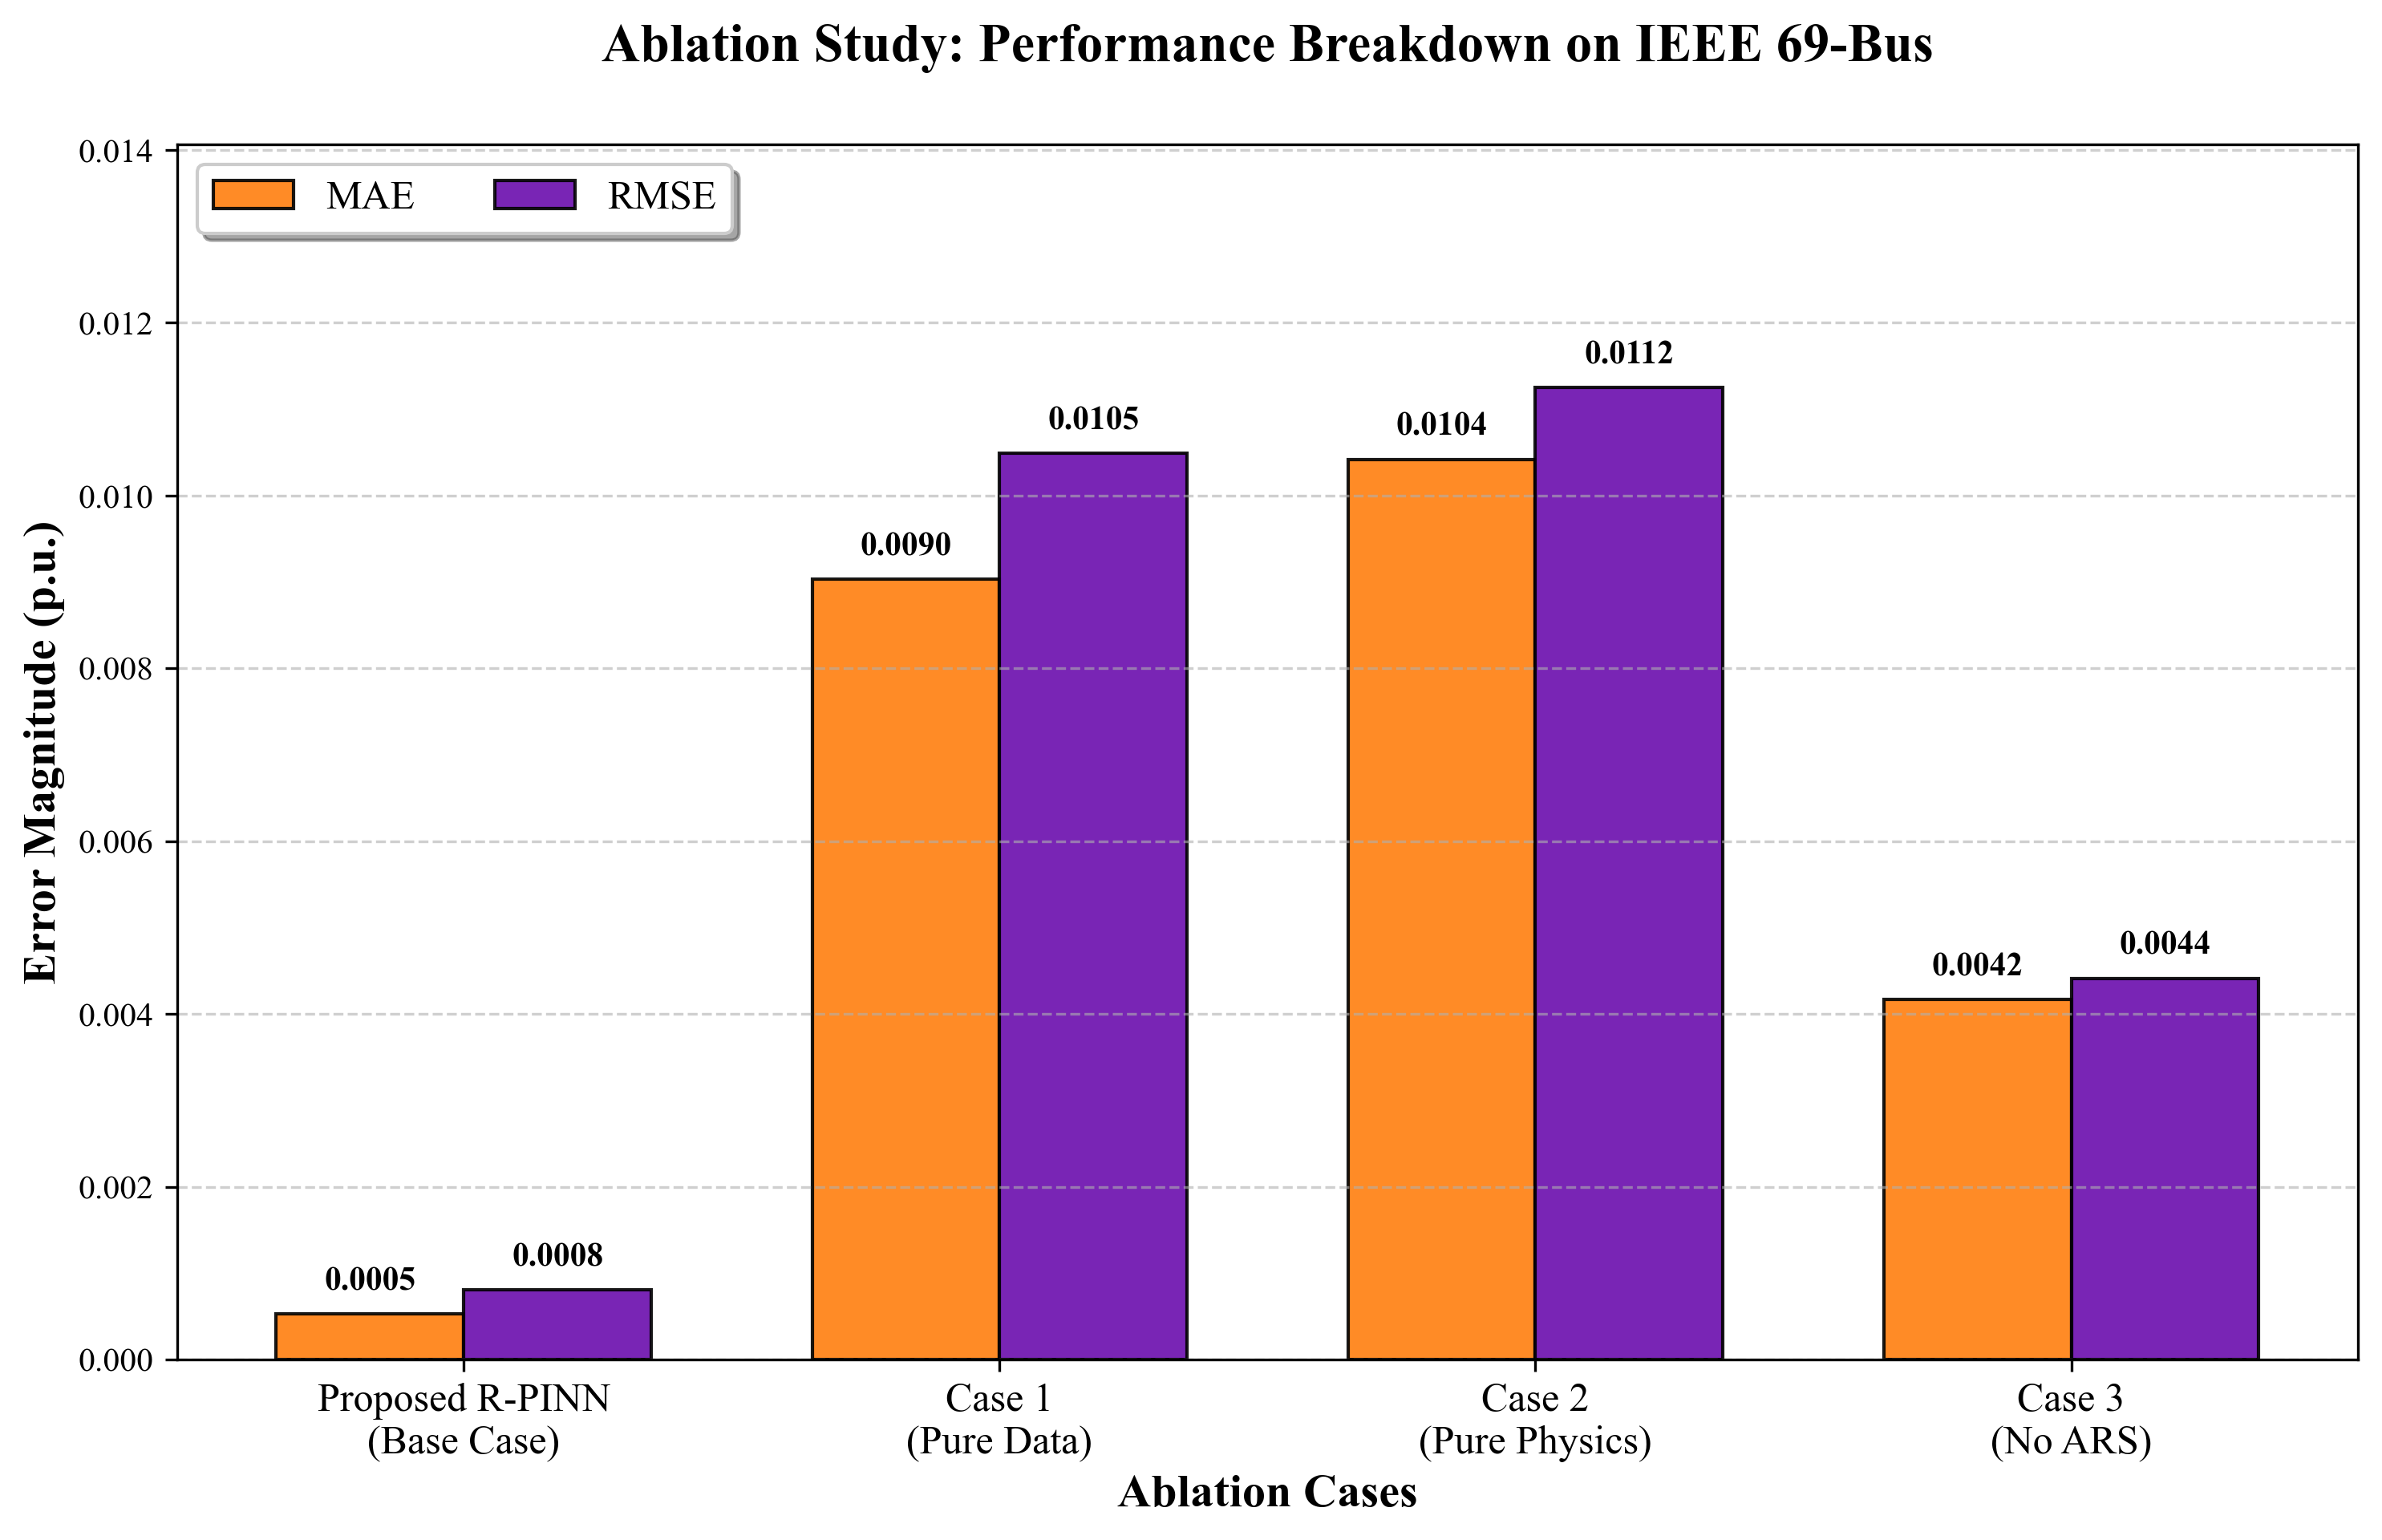

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# ⚙️ 1. 全局学术排版设置 (Times New Roman + 300 DPI)
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300

# 场景标签
labels = ['Proposed R-PINN\n(Base Case)', 'Case 1\n(Pure Data)', 'Case 2\n(Pure Physics)', 'Case 3\n(No ARS)']
x = np.arange(len(labels))
width = 0.35  # 单个柱子的宽度

# ==========================================================
# 🚨 核心数据录入区 (MAE vs RMSE)
# ==========================================================
# Proposed: MAE 5.3215e-04, RMSE 8.0952e-04
# Case 1: MAE 9.0326e-03, RMSE 1.0486e-02
# Case 2: MAE 1.0418e-02, RMSE 1.1248e-02
# Case 3: MAE 4.1699e-03, RMSE 4.4135e-03

mae_data = [0.000532, 0.009033, 0.010418, 0.004170]
rmse_data = [0.000810, 0.010486, 0.011248, 0.004414]

fig, ax = plt.subplots(figsize=(10, 6.5))

# 绘制双柱：MAE, RMSE
rects1 = ax.bar(x - width/2, mae_data, width, label='MAE', color='#ff7f0e', edgecolor='black', alpha=0.9)
rects2 = ax.bar(x + width/2, rmse_data, width, label='RMSE', color='#6a0dad', edgecolor='black', alpha=0.9)

# 🚀 数值标签 (四位小数显示)
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5点向上偏移
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

add_labels(rects1)
add_labels(rects2)

# ==========================================================
# 坐标轴与标题设置
# ==========================================================
ax.set_ylabel('Error Magnitude (p.u.)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ablation Cases', fontsize=14, fontweight='bold')
ax.set_title('Ablation Study: Performance Breakdown on IEEE 69-Bus', fontsize=16, fontweight='bold', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

ax.set_ylim(0, max(rmse_data) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, ncol=2)

plt.tight_layout()
plt.savefig('ieee69_ablation_mae_rmse.png', dpi=600, bbox_inches='tight')
plt.show()